# 01 — Exploratory Data Analysis

## Assessment Task

The assessment asks us to **optimise loan limit increases** for a customer base in 2023.

Key points from the specification:

| Parameter | Value |
|-----------|-------|
| Eligibility | 60 days after previous loan, on-time repayments |
| Max increases | up to 6 per year |
| Profit per increase | $40 (before risk adjustment) |
| Default risk | must be factored into expected return |
| Discount rate | 19% annual for NPV |
| Capital constraints | total exposure within predefined thresholds |
| External factors | inflation, unemployment, interest rates |

Required deliverables: dynamic forecasting model, optimisation model, risk evaluation via probabilistic models, loan lifecycle simulation.

## EDA Goal

This notebook walks through the dataset from loading to anomaly detection, feature engineering, and correlation analysis.

We answer:

1. What does the data look like? (shape, quality, distributions)
2. What structural anomalies exist? (6 anomalies A1–A6)
3. Does `total_profit` match the business spec?
4. Are features informative for modelling?
5. How should we frame the optimisation problem?

| Notebook | Topic |
|----------|-------|
| **01 EDA** | Exploratory Data Analysis ← here |
| 02 Markov | Markov Chain Risk Modelling |
| 03 Demand | Stochastic Demand Forecasting |
| 04 Optimisation | Portfolio Optimisation |
| 05 Monte Carlo | NPV Simulation |

In [1]:
import sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

ROOT = Path().cwd().parent
sys.path.insert(0, str(ROOT / 'src'))

from eda_plots import (
    plot_distributions,
    plot_correlation,
    plot_a1_missing_n,
    plot_a2_otp_analysis,
    plot_a3_ks_uniform,
    plot_a4_independence,
    plot_a5_eligibility,
    plot_profit_rule_comparison,
    plot_received_vs_eligible_zero,
    plot_risk_vs_uptake,
    plot_segments,
)

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

# Business constants from the assessment
PROFIT_PER_INCREASE    = 40
ANNUAL_DISCOUNT_RATE   = 0.19
MONTHLY_DISC_RATE      = (1 + ANNUAL_DISCOUNT_RATE) ** (1/12) - 1
MAX_INCREASES_PER_YEAR = 6
ELIGIBILITY_DAYS       = 60
CAPITAL_LIMIT_RATIO    = 0.30
SEED = 42
np.random.seed(SEED)

RISK_LABELS = {0: 'Prime', 1: 'Near-Prime', 2: 'Sub-Prime'}
RISK_COLORS = {0: '#2ecc71', 1: '#f39c12', 2: '#e74c3c'}

print(f'Monthly discount rate: {MONTHLY_DISC_RATE*100:.4f}%  (annual 19%)')

Monthly discount rate: 1.4602%  (annual 19%)


---
## 1. Load & First Look

The dataset is a CSV with 30,000 records. We rename columns to snake_case for convenience.

In [2]:
df = pd.read_csv(ROOT / 'data' / 'loan_limit_increases.csv')
df.columns = [
    'customer_id', 'initial_loan', 'days_since_last_loan',
    'on_time_pct', 'n_increases_2023', 'total_profit'
]

print(f'Shape: {df.shape}  |  Unique IDs: {df["customer_id"].nunique():,}  |  Duplicates: {df.duplicated().sum()}')
print(f'Missing values: {df.isna().sum().sum()}\n')
display(df.describe().round(2))
df.head()

Shape: (30000, 6)  |  Unique IDs: 30,000  |  Duplicates: 0
Missing values: 0



,customer_id,initial_loan,days_since_last_loan,on_time_pct,n_increases_2023,total_profit
count,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00
mean,16000.50,2752.53,181.48,90.02,2.24,44.72
std,8660.40,1293.03,105.07,5.75,2.08,46.63
min,1001.00,500.00,0.00,80.00,0.00,0.00
25%,8500.75,1630.00,90.00,85.08,0.00,0.00
50%,16000.50,2761.00,182.00,90.05,3.00,40.00
75%,23500.25,3866.00,272.00,95.01,4.00,80.00
max,31000.00,4999.00,364.00,100.00,5.00,120.00


,customer_id,initial_loan,days_since_last_loan,on_time_pct,n_increases_2023,total_profit
0,1001,1360,72,90.41,5,120
1,1002,4272,54,90.32,0,0
2,1003,3592,242,85.56,4,80
3,1004,966,301,95.86,0,0
4,1005,4926,352,94.80,0,0


**Data window interpretation**

This is best treated as a **2023 snapshot-like dataset**:

- `n_increases_2023 = 0` means no increases during 2023, not necessarily no increases ever.
- Previous years are hidden.
- `days_since_last_loan` is observed status at snapshot date.
- Any full customer history statement is an assumption, not a fact.

---
## 2. Distributions

All three continuous features appear Uniform — no skew, no peaks.
The discrete `n_increases` bar chart already reveals structural gaps at {1, 2, 6}.

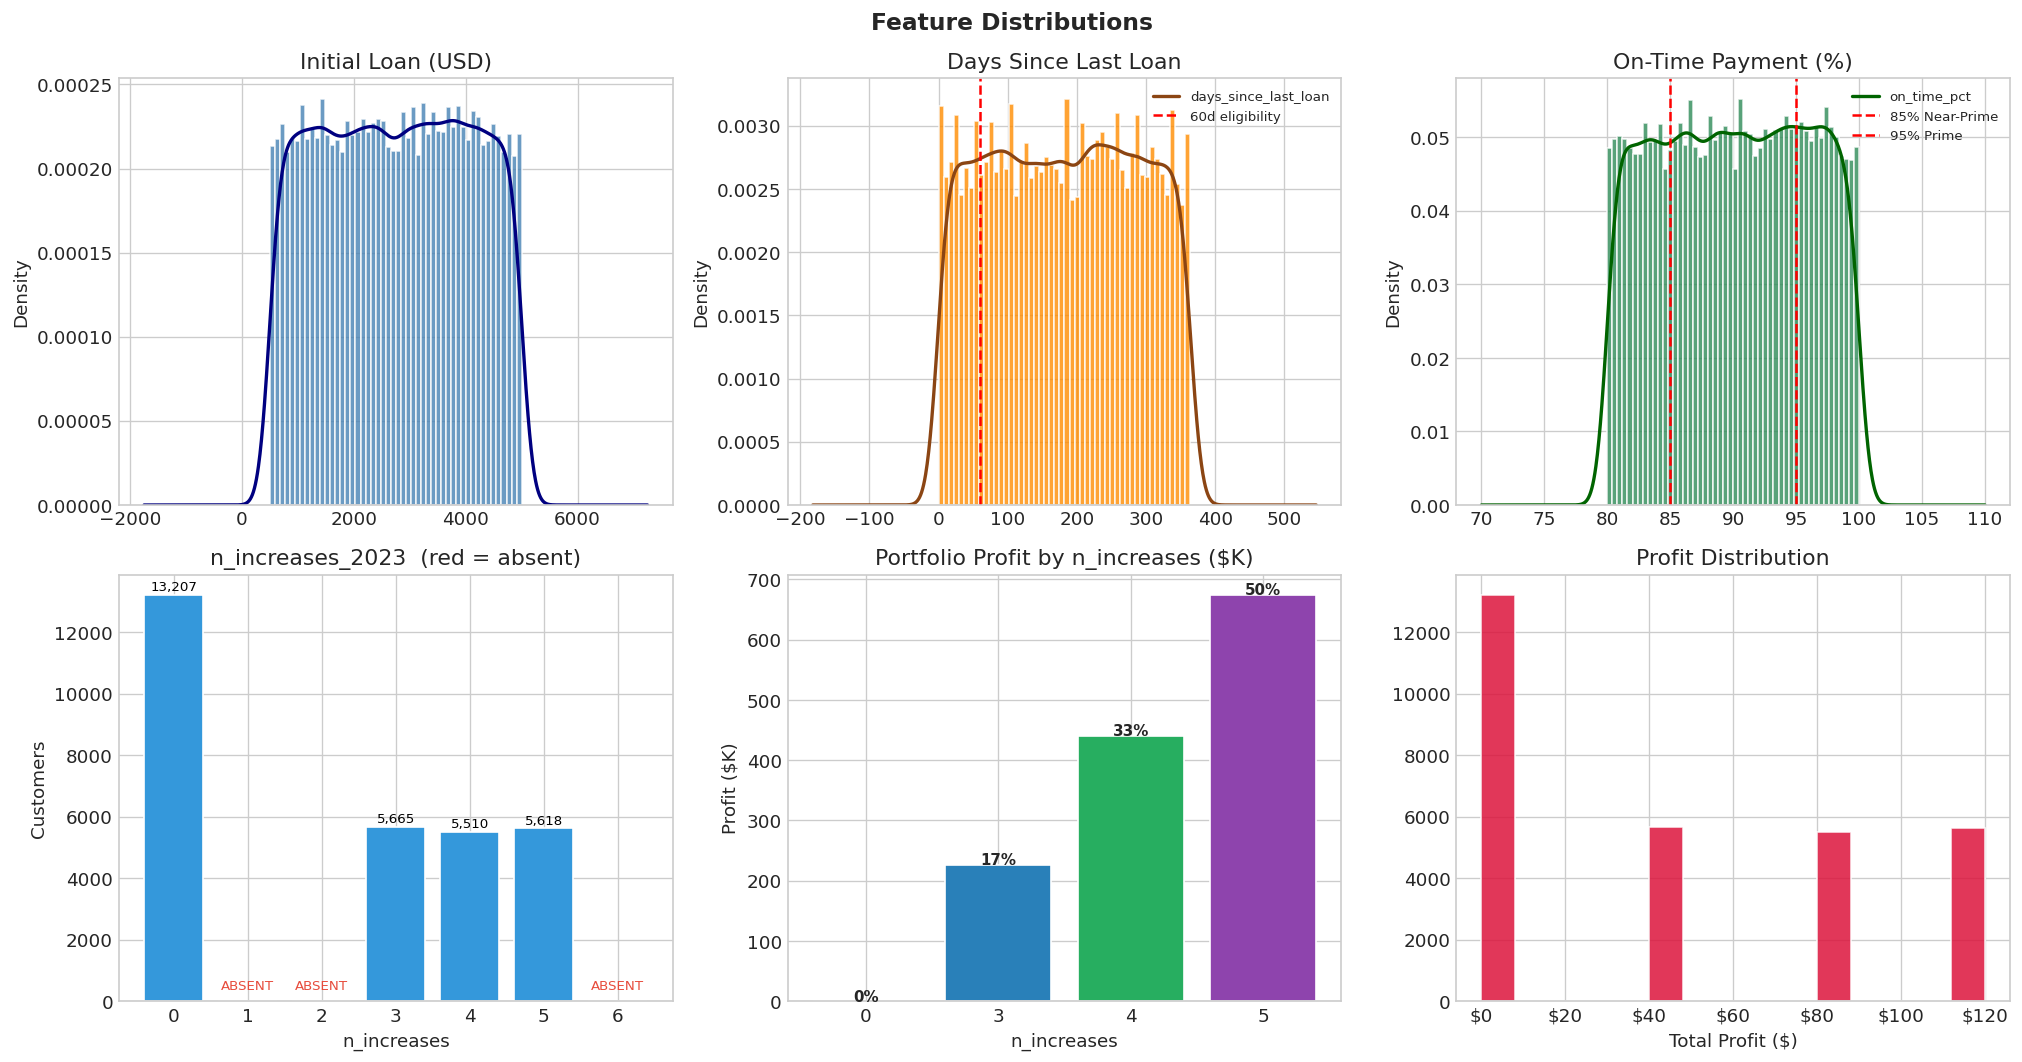

In [3]:
plot_distributions(df, eligibility_days=ELIGIBILITY_DAYS)

---
## 3. Correlations

`n_increases` and `total_profit` show high but **imperfect** correlation (~0.97).
The cause: the `max(0, n−2)` kink puts 44% of customers at point (0, $0) — above the linear trend through (3, $40), (4, $80), (5, $120).

All input features are near-zero correlated with each other and with the target — consistent with synthetic random generation.

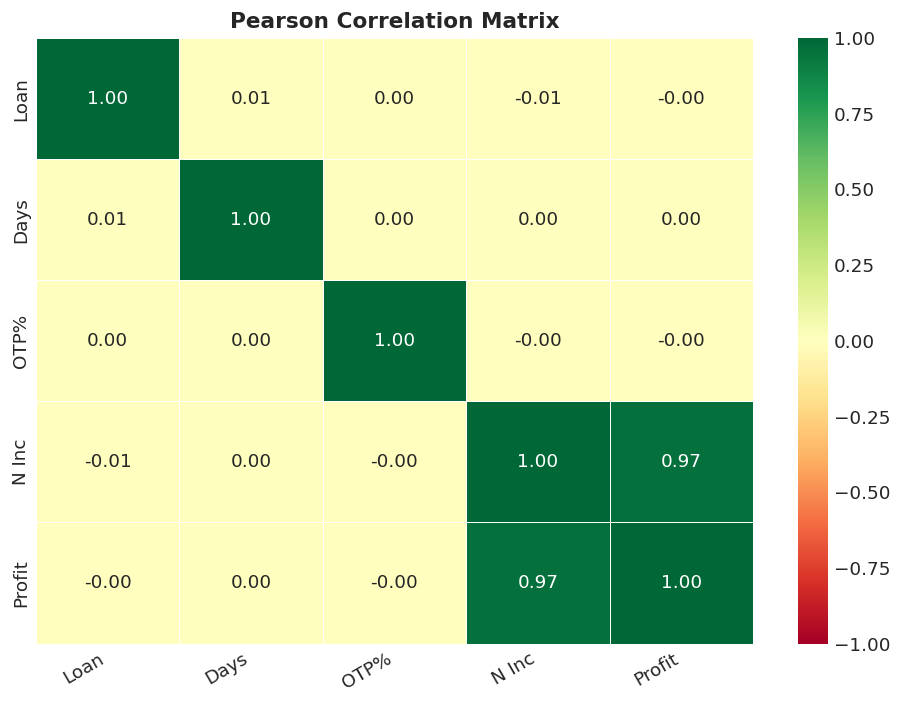


Top correlations with n_increases_2023:
  total_profit                : +0.9679
  initial_loan                : -0.0056
  days_since_last_loan        : +0.0036
  on_time_pct                 : -0.0001


In [4]:
corr_cols   = ['initial_loan', 'days_since_last_loan', 'on_time_pct',
               'n_increases_2023', 'total_profit']
corr_labels = ['Loan', 'Days', 'OTP%', 'N Inc', 'Profit']

corr = plot_correlation(df, corr_cols, corr_labels)

print('\nTop correlations with n_increases_2023:')
for feat, val in (corr['n_increases_2023']
                     .drop('n_increases_2023')
                     .sort_values(key=abs, ascending=False)
                     .items()):
    print(f'  {feat:<28}: {val:+.4f}')

---
## 4. Anomaly Detection

Six structural patterns that change the modelling approach:

| # | Anomaly | Impact |
|---|---------|--------|
| **A1** | `n_increases` only {0,3,4,5} — {1,2,6} structurally absent | High |
| **A2** | `on_time_pct` bounded [80,100]; spec thresholds 85/95 cut at P25/P75 | Medium |
| **A3** | All continuous features are Uniform (KS p > 0.30) | High |
| **A4** | Features statistically independent of target (ANOVA p > 0.30) | Critical |
| **A5** | 2,726 ineligible customers received increases anyway | Critical |
| **A6** | `total_profit` does not match the task formula `40 × n` | High |

These confirm the dataset is **fully synthetic** and historical allocations were **not quality-based**.
This justifies designing a new optimisation policy from first principles.

### A1 — Missing n_increases Values {1, 2, 6}

Only {0, 3, 4, 5} appear. In any real gradual roll-out, customers would receive 1 or 2 increases before reaching 3.

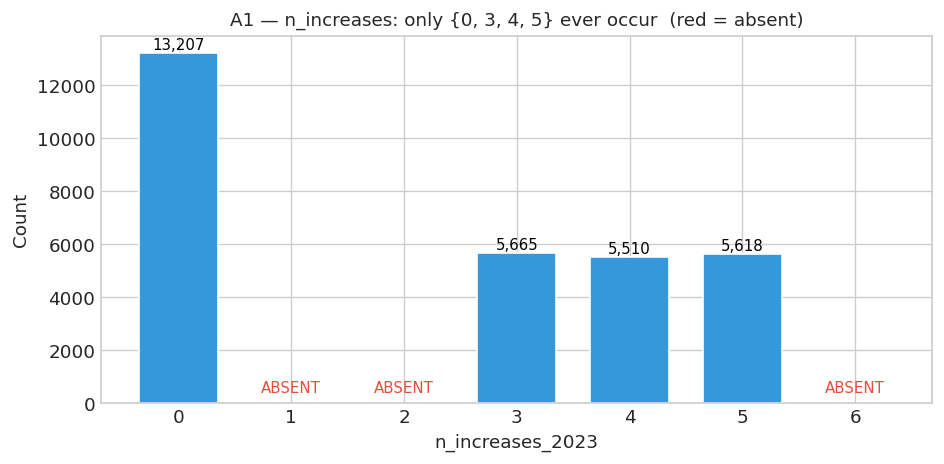

Observed n_increases_2023 values: [0, 3, 4, 5]
Absent values: {1, 2, 6}


In [5]:
plot_a1_missing_n(df)

print('Observed n_increases_2023 values:', sorted(df['n_increases_2023'].unique().tolist()))
print('Absent values: {1, 2, 6}')

### A2 — on_time_pct: Hard Floor at 80%

Uniform on [80%, 100%]. Spec thresholds 85%/95% cut at the 25th/75th percentile — not at any natural break.
Real portfolios are right-skewed with a cluster of high-risk borrowers below 80%.

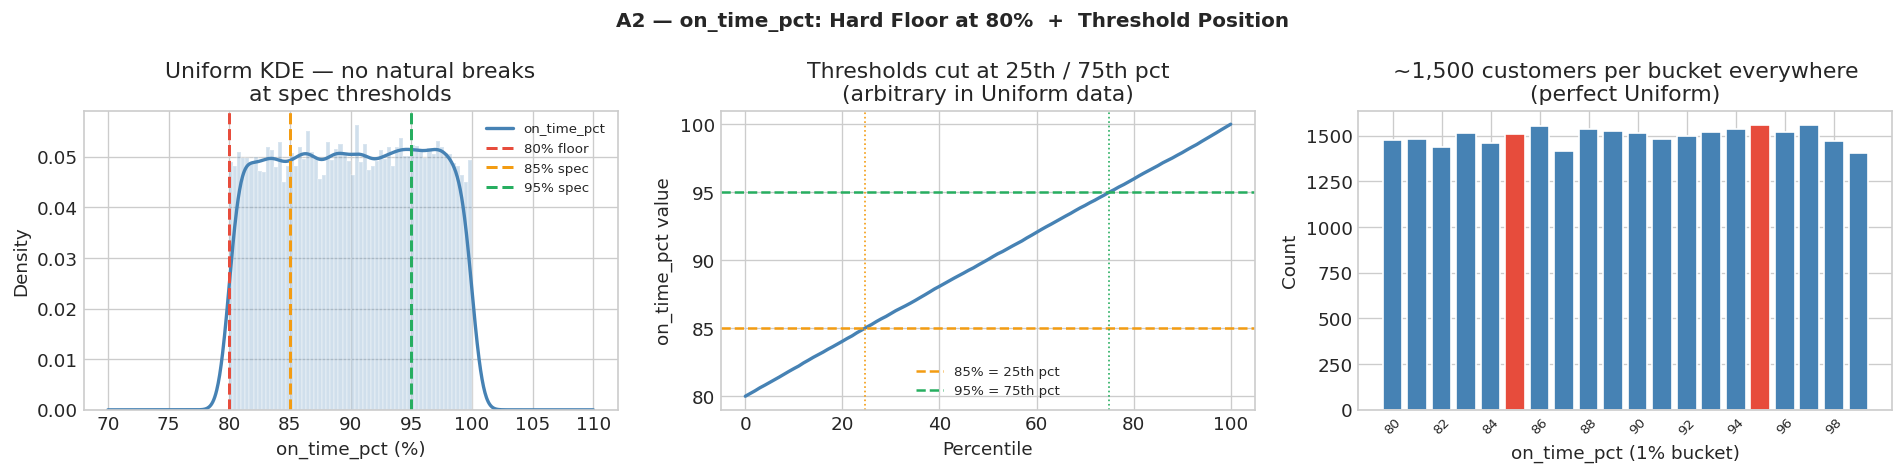


on_time_pct  min=80.0%  max=100.0%
85% threshold = 25th percentile
95% threshold = 75th percentile


In [6]:
plot_a2_otp_analysis(df)

print(f'\non_time_pct  min={df["on_time_pct"].min():.1f}%  max={df["on_time_pct"].max():.1f}%')
print(f'85% threshold = {(df["on_time_pct"]<85).mean()*100:.0f}th percentile')
print(f'95% threshold = {(df["on_time_pct"]<95).mean()*100:.0f}th percentile')

### A3 — All Continuous Features Are Uniform

KS test vs Uniform(lo, hi): all p > 0.30.
Real loan portfolios show normal or log-normal loan amounts and heavily skewed payment histories.

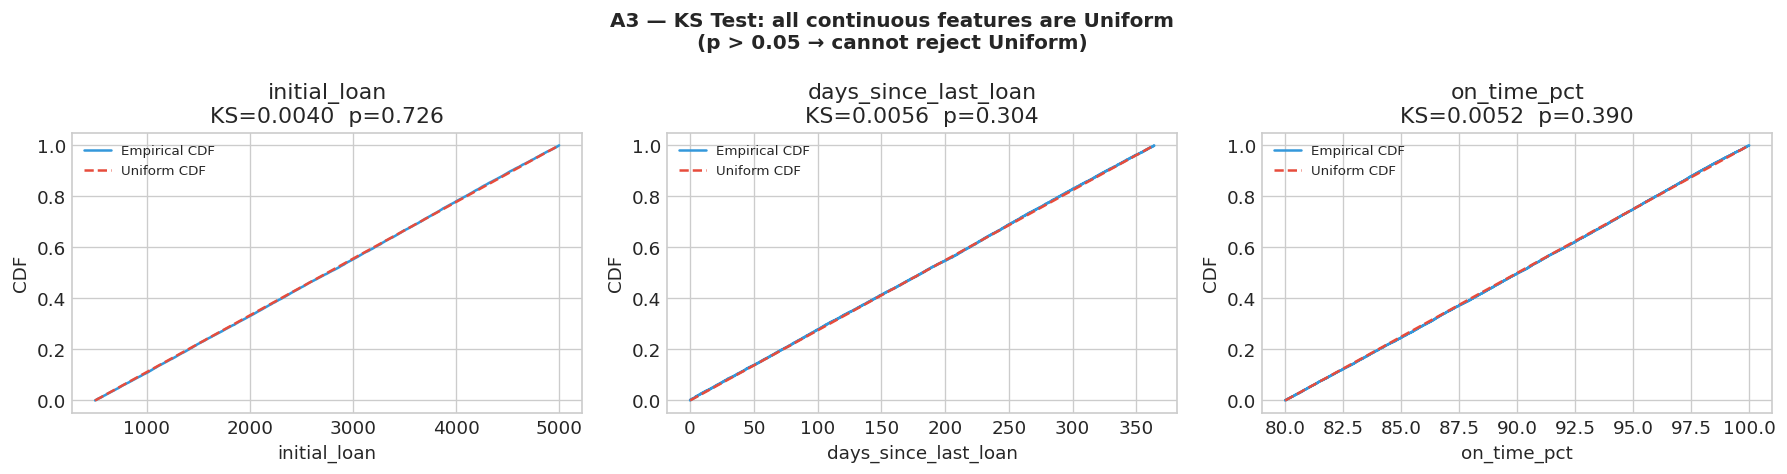


  initial_loan                : KS=0.0040  p=0.7263  → cannot reject Uniform
  days_since_last_loan        : KS=0.0056  p=0.3043  → cannot reject Uniform
  on_time_pct                 : KS=0.0052  p=0.3905  → cannot reject Uniform


In [7]:
cont_features = ['initial_loan', 'days_since_last_loan', 'on_time_pct']
ks_results = plot_a3_ks_uniform(df, cont_features)

print()
for r in ks_results:
    print(f'  {r["feature"]:<28}: KS={r["KS"]:.4f}  p={r["p"]:.4f}  → cannot reject Uniform')

### A4 — Features Are Independent of the Target

If increases were quality-based, Prime customers (high `on_time_pct`) would have higher `n_increases`.
ANOVA shows feature means are flat across all groups, and chi-square confirms independence.

**Increases were assigned at random** — no ML model can learn a meaningful signal from historical `received`.

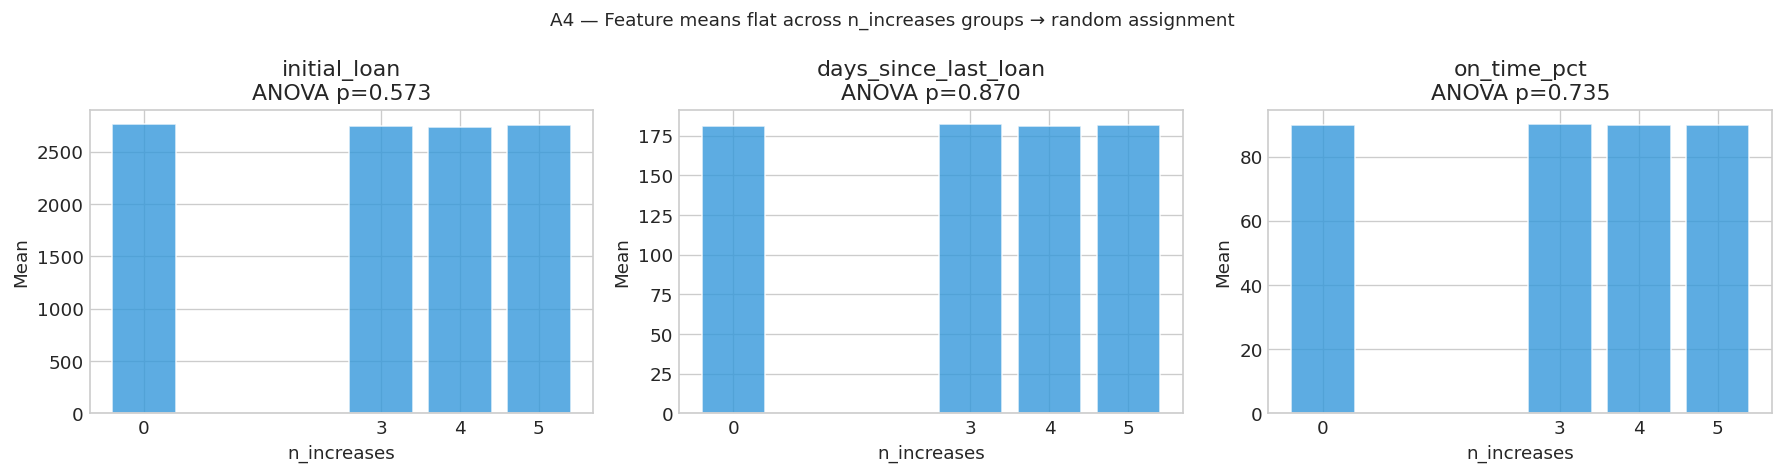

Chi-square (n_increases × risk_state): chi2=2.084  dof=6  p=0.9118  → INDEPENDENT
ANOVA initial_loan                : F=0.665  p=0.5733  → INDEPENDENT
ANOVA days_since_last_loan        : F=0.238  p=0.8702  → INDEPENDENT
ANOVA on_time_pct                 : F=0.425  p=0.7354  → INDEPENDENT


In [8]:
plot_a4_independence(df, cont_features)

### A5 — 60-Day Eligibility Rule Violated

Customers with `days_since_last_loan < 60` should have received zero increases.
Instead 2,726 of them received increases with nearly the same uptake rate as eligible customers.

**The rule must be enforced going forward** — it is a hard constraint in the optimiser.

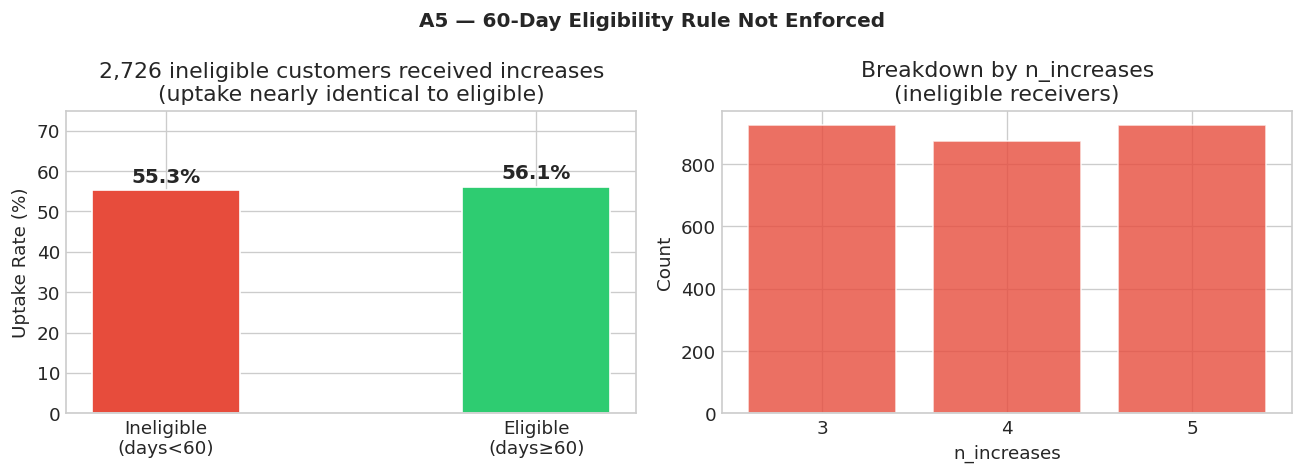

Ineligible (days<60): 4,932  |  received: 2,726  (55.3%)
Eligible   (days≥60): 25,068  |  uptake: 56.1%
Gap: 0.8 pp  → rule had no effect


In [9]:
plot_a5_eligibility(df, eligibility_days=ELIGIBILITY_DAYS)

### A6 — total_profit Does Not Match Task Specification

The assessment says each increase generates **$40 profit**. So the expected formula is `40 × n`.

The dataset uses `max(0, n−2) × 40` instead. We compare three candidates:

1. **Task specification:** `40 × n`
2. **Activation hypothesis:** `40 × max(0, n−1)` — first increase is activation only
3. **Observed dataset rule:** `40 × max(0, n−2)`

If activation were correct, `n=3` should give $80. But data gives $40. So activation doesn't fit either.

`total_profit` is a **synthetic field**, not the business objective from the assessment.

Profit rule max(0, n−2)×$40 confirmed for all 30,000 rows


,n_increases_2023,customers,observed_profit,spec_profit,activation_profit,match_spec,match_activation
0,0,13207,0.0,0,0,True,True
1,3,5665,40.0,120,80,False,False
2,4,5510,80.0,160,120,False,False
3,5,5618,120.0,200,160,False,False


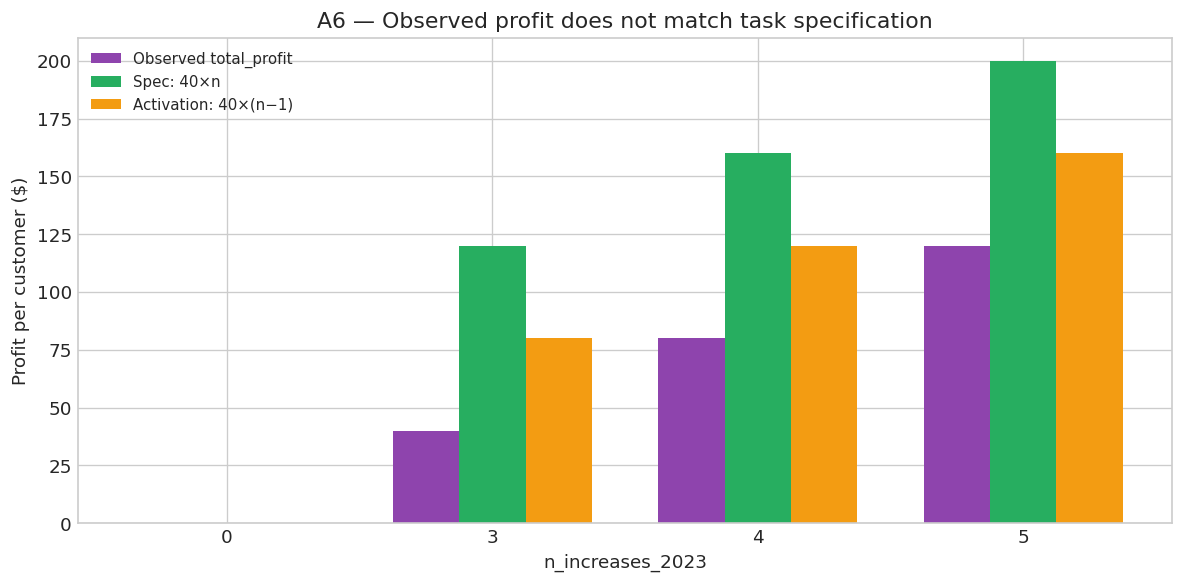


Pearson r(n_increases, total_profit) = 0.9679
Only max(0, n−2)×$40 matches the data. Use spec (40×n) for optimisation.


In [10]:
# Verify the data rule holds for all rows
check = np.maximum(0, df['n_increases_2023'] - 2) * PROFIT_PER_INCREASE
assert (check == df['total_profit']).all(), 'Rule violated!'
print(f'Profit rule max(0, n−2)×$40 confirmed for all {len(df):,} rows')

# Build comparison table
rule_table = (df.groupby('n_increases_2023')
               .agg(customers=('customer_id', 'count'),
                    observed_profit=('total_profit', 'mean'))
               .reset_index())
rule_table['spec_profit']       = rule_table['n_increases_2023'] * PROFIT_PER_INCREASE
rule_table['activation_profit'] = np.maximum(0, rule_table['n_increases_2023'] - 1) * PROFIT_PER_INCREASE
rule_table['match_spec']        = rule_table['observed_profit'] == rule_table['spec_profit']
rule_table['match_activation']  = rule_table['observed_profit'] == rule_table['activation_profit']

display(rule_table)

plot_profit_rule_comparison(rule_table)

corr_val = df[['n_increases_2023', 'total_profit']].corr().iloc[0, 1]
print(f'\nPearson r(n_increases, total_profit) = {corr_val:.4f}')
print('Only max(0, n−2)×$40 matches the data. Use spec (40×n) for optimisation.')

---
## 5. Eligible but No Increases vs Received

We compare:
- customers with zero increases who are currently eligible (`days_since_last_loan ≥ 60`)
- customers who received at least one increase

The first group is **not automatically a refusal group** — they may not have been offered an increase, may have been blocked by hidden rules, or may have declined.

This is better interpreted as **policy / selection bias**, not pure customer choice.

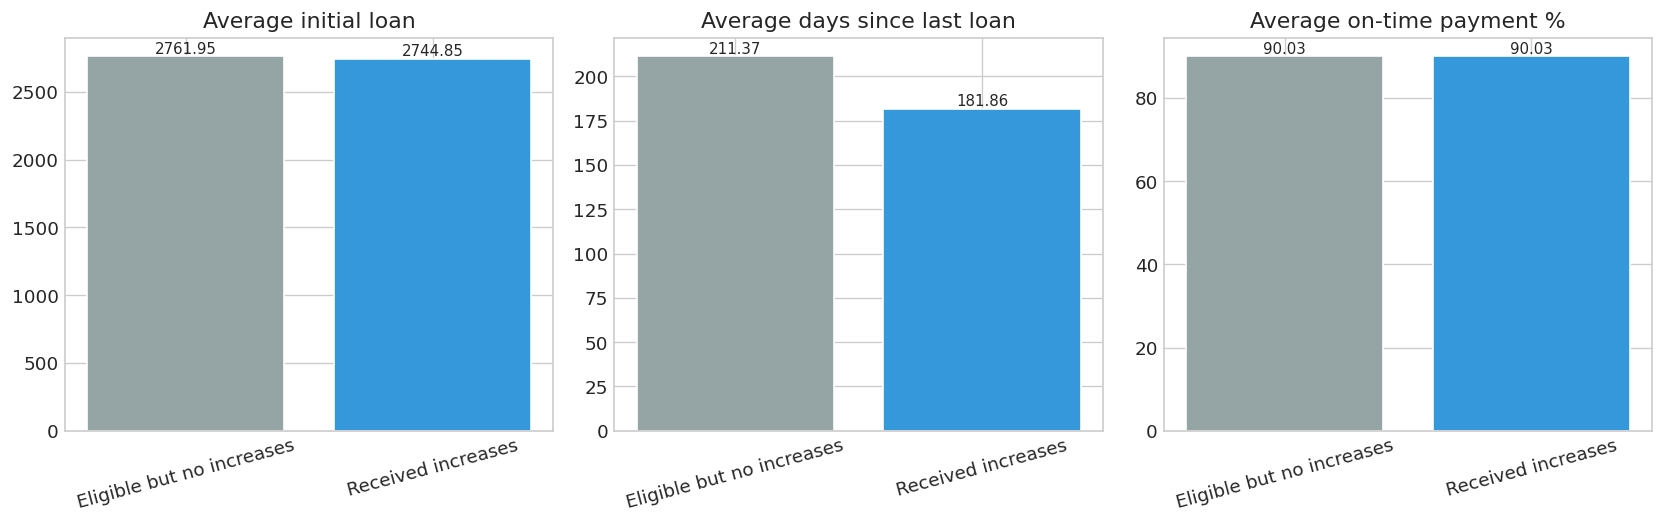

,group,customers,avg_initial_loan,avg_days_since_last_loan,avg_on_time_pct
0,Eligible but no increases,11001,2761.95,211.37,90.03
1,Received increases,16793,2744.85,181.86,90.03


The two groups look very similar on loan size and on_time_pct.
Historical allocation was likely influenced by hidden policy rules, not customer quality.


In [11]:
group_compare = plot_received_vs_eligible_zero(df, eligibility_days=ELIGIBILITY_DAYS)
display(group_compare.round(2))

print('The two groups look very similar on loan size and on_time_pct.')
print('Historical allocation was likely influenced by hidden policy rules, not customer quality.')

---
## 6. Feature Engineering

We derive features needed by downstream notebooks. Created **after** anomaly analysis so raw data speaks first.

In [12]:
def assign_risk(pct):
    return 0 if pct >= 95 else (1 if pct >= 85 else 2)

df['risk_state']  = df['on_time_pct'].apply(assign_risk)
df['risk_label']  = df['risk_state'].map(RISK_LABELS)
df['eligible']    = (df['days_since_last_loan'] >= ELIGIBILITY_DAYS).astype(int)
df['received']    = (df['n_increases_2023'] > 0).astype(int)
df['max_possible_increases'] = (
    df['days_since_last_loan'].clip(upper=365)
      .floordiv(ELIGIBILITY_DAYS)
      .clip(upper=MAX_INCREASES_PER_YEAR)
      .astype(int)
)
df['utilisation_rate'] = (
    (df['initial_loan'] - df['initial_loan'].min()) /
    (df['initial_loan'].max() - df['initial_loan'].min())
)
df['incremental_profit'] = np.maximum(0, df['n_increases_2023'] - 2) * PROFIT_PER_INCREASE

print('Features added:')
for col, desc in [
    ('risk_state',             '0=Prime / 1=Near-Prime / 2=Sub-Prime'),
    ('risk_label',             'text label for risk_state'),
    ('eligible',               '1 if days_since_last_loan >= 60'),
    ('received',               '1 if n_increases_2023 > 0'),
    ('max_possible_increases', 'floor(days/60) capped at 6'),
    ('utilisation_rate',       'initial_loan normalised to [0, 1]'),
    ('incremental_profit',     'max(0, n-2) x $40'),
]:
    print(f'  {col:<28}: {desc}')

print()
for s in [0, 1, 2]:
    n = (df['risk_state'] == s).sum()
    print(f'  {RISK_LABELS[s]:<12}: {n:,} ({n/len(df)*100:.1f}%)')

n_elig = df['eligible'].sum()
print(f'\n  Eligible: {n_elig:,} ({n_elig/len(df)*100:.1f}%)  |  '
      f'Received: {df["received"].sum():,} ({df["received"].mean()*100:.1f}%)')

Features added:
  risk_state                  : 0=Prime / 1=Near-Prime / 2=Sub-Prime
  risk_label                  : text label for risk_state
  eligible                    : 1 if days_since_last_loan >= 60
  received                    : 1 if n_increases_2023 > 0
  max_possible_increases      : floor(days/60) capped at 6
  utilisation_rate            : initial_loan normalised to [0, 1]
  incremental_profit          : max(0, n-2) x $40

  Prime       : 7,520 (25.1%)
  Near-Prime  : 15,103 (50.3%)
  Sub-Prime   : 7,377 (24.6%)

  Eligible: 25,068 (83.6%)  |  Received: 16,793 (56.0%)


---
## 7. Segment Validation

Confirming all three risk tiers show identical behaviour — zero signal, consistent with anomaly A4.

This also shows where `on_time_pct` should **not** enter the model: as a revenue multiplier.
Instead it should enter through **risk adjustment** (PD):

$$EV_i = x_i \times (40 - PD_i \times LGD_i \times EAD_i)$$

where `PD_i` is driven by `on_time_pct` or a derived `risk_state`.

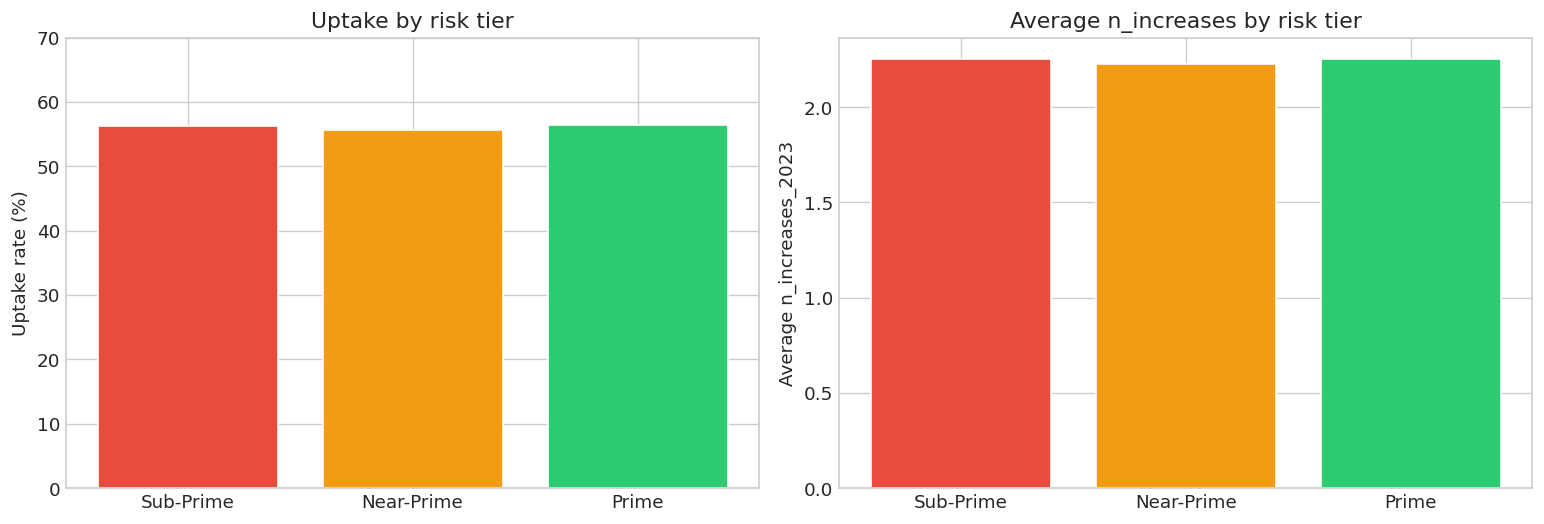

,risk_state,customers,avg_otp,pct_received,avg_n
0,Sub-Prime,7377,82.492,0.562,2.251
1,Near-Prime,15103,90.006,0.557,2.224
2,Prime,7510,97.446,0.564,2.252


Uptake and average n are almost flat across risk tiers.
Historical increases were not driven by repayment quality.


In [13]:
risk_summary = plot_risk_vs_uptake(df)
display(risk_summary.round(3))

print('Uptake and average n are almost flat across risk tiers.')
print('Historical increases were not driven by repayment quality.')

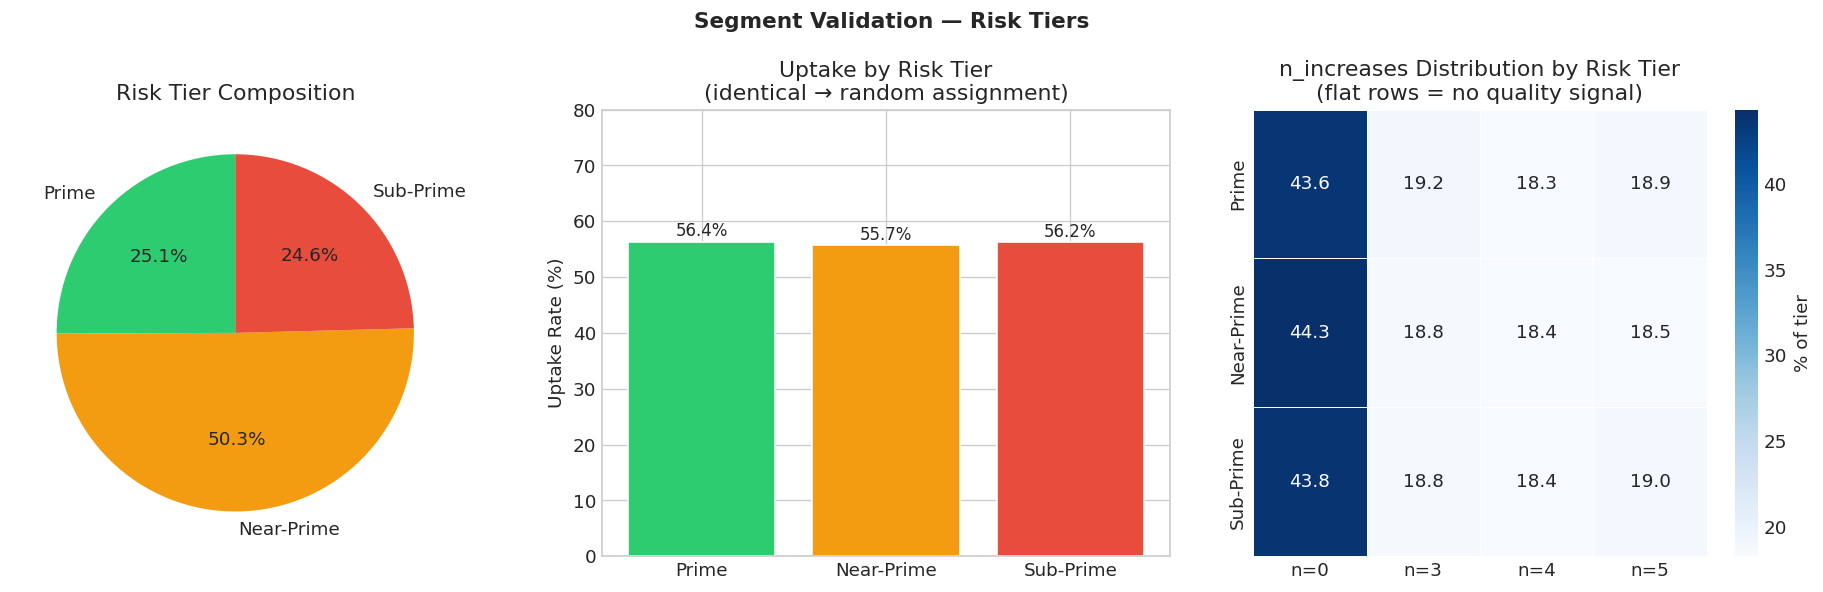


Segment summary:


,n,pct_received,avg_n,avg_otp,avg_profit
risk_label,,,,,
Prime,7520,0.564,2.252,97.450,44.979
Near-Prime,15103,0.557,2.224,90.006,44.420
Sub-Prime,7377,0.562,2.251,82.492,45.064



n_increases distribution by risk tier (%):


,n=0,n=3,n=4,n=5
risk_state,,,,
Prime,43.6,19.2,18.3,18.9
Near-Prime,44.3,18.8,18.4,18.5
Sub-Prime,43.8,18.8,18.4,19.0


In [14]:
seg, pivot = plot_segments(df, RISK_COLORS, RISK_LABELS)

print('\nSegment summary:')
display(seg[['n', 'pct_received', 'avg_n', 'avg_otp', 'avg_profit']].round(3))
print('\nn_increases distribution by risk tier (%):')
display(pivot)

---
## 8. Key Findings

### Data is Fully Synthetic

Six independent anomalies confirm it (A1–A6). The true generation process is:
Uniform draws + random discrete assignment. No historical selection bias exists.

### This is an Optimisation Problem, Not a Prediction Problem

Past allocations were random (A4). No signal exists to predict who "deserves" an increase.
The task is to design an **allocation rule** that maximises portfolio profit under hard constraints.

### Untapped Profit

~11,000 eligible customers received zero increases. Their quality is statistically identical
to the n={3,4,5} groups (A4 confirmed). Re-allocating to them is the primary profit lever.

### Profit Function

- **Business objective:** `40 × n` per customer (from the assessment specification)
- **Risk-adjusted:** `40 − PD × LGD × EAD` per granted increase
- **Dataset field:** `total_profit = max(0, n−2) × 40` — synthetic artifact, **not** the optimisation target

### Constraints for Optimisation

| Constraint | Value |
|------------|-------|
| Eligibility | `days_since_last_loan ≥ 60` |
| Max increases | ≤ 6 per customer per year |
| Capital limit | ≤ 30% of portfolio exposed |
| NPV discount | 19% p.a. → 1.46% per month |
| Profit per increase | $40 (before risk adjustment) |

### Synthetic Data Advantages

1. True distributions are known → Monte Carlo simulation is exact
2. No bias → allocation from first principles
3. Feature independence → LP / MIP has no multicollinearity issues
4. Profit formula is exact → analytical validation of optimiser output

### External Risk Factors (for Notebook 03)

The dataset has no macro variables. We model them as scenario inputs:

| Factor | Pessimistic | Base | Optimistic |
|--------|-------------|------|------------|
| Inflation | +3pp | 0pp | −1pp |
| Unemployment | +2pp | 0pp | −1pp |
| Interest rate | +100bp | 0bp | −50bp |
| Default prob adj. | +20% | 0% | −10% |

---
## 9. Export

Save `df_features.csv` with all engineered columns for downstream notebooks (02–05).

In [15]:
import os
os.makedirs(str(ROOT / 'data'), exist_ok=True)

out = ROOT / 'data' / 'df_features.csv'
df.to_csv(out, index=False)

print(f'Saved: {out}')
print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')

Saved: /data/aturov/loan_limit_increases/data/df_features.csv
Shape: (30000, 13)
Columns: ['customer_id', 'initial_loan', 'days_since_last_loan', 'on_time_pct', 'n_increases_2023', 'total_profit', 'risk_state', 'risk_label', 'eligible', 'received', 'max_possible_increases', 'utilisation_rate', 'incremental_profit']
